Data starts at row: 8
Cleaned data after removing induction period (first few rows):
     Time  Sample1  Sample2  Sample3  Sample4  Sample5  Sample6  Sample7
19   60.0    0.004   -0.001   -0.002   -0.004   -0.002   -0.009   -0.003
20  120.0    0.004   -0.001   -0.001   -0.003   -0.001   -0.010   -0.003
21  180.0    0.005    0.000   -0.001   -0.003   -0.001   -0.009   -0.003
22  240.0    0.005    0.000    0.000   -0.003    0.000   -0.009   -0.003
23  300.0    0.006    0.000    0.000   -0.002    0.000   -0.009   -0.003


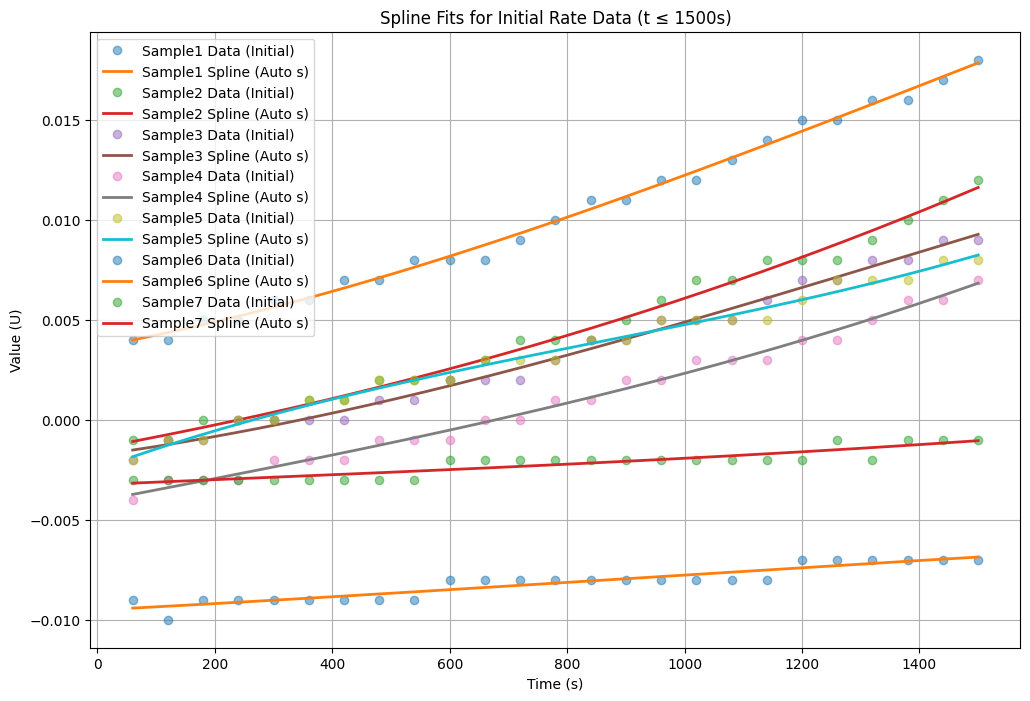

Initial rates (derivative at t=0):
Sample1: 5.490833643007586e-06 U/s
Sample2: 5.413002188364513e-06 U/s
Sample3: 3.9791073124406325e-06 U/s
Sample4: 5.615942028985505e-06 U/s
Sample5: 1.0598703497254214e-05 U/s
Sample6: 1.5397002353523746e-06 U/s
Sample7: 1.2315743837482896e-06 U/s


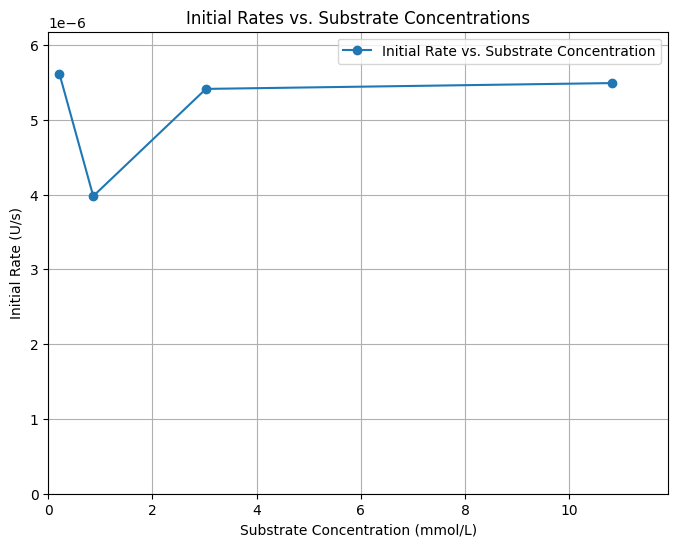

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline

# Load the raw data
file_path = '/home/madsr2d2/masterThesis/data/Mads/No enzyme/data3.txt'  # Adjust as needed
file_path = '/home/madsr2d2/masterThesis/data/Mads/good data BnOH/data138.txt'  # Adjust as needed

# Read the data with the correct delimiter (tab-separated)
# Read the data with the correct delimiter (tab-separated)
raw_data = pd.read_csv(file_path, delimiter='\t', header=None)

# Automatically detect the row where t = 0
data_start_row = None
for i, row in raw_data.iterrows():
    try:
        # Check if the first column contains t = 0
        if float(row[0]) == 0:
            data_start_row = i
            break
    except ValueError:
        continue  # Skip rows with non-numeric values

if data_start_row is None:
    raise ValueError("Could not find the row where t = 0 in the dataset.")

print(f"Data starts at row: {data_start_row}")

# Extract data starting from the detected row
numeric_data = raw_data.iloc[data_start_row:, :]

# Drop rows with missing values
numeric_data = numeric_data.dropna()

# Dynamically extract time and value columns
num_columns = numeric_data.shape[1]  # Total number of columns
if num_columns % 2 != 0:
    raise ValueError("The number of columns in the raw data is not even, expected time-value pairs.")

# Identify time and value columns
time_columns = numeric_data.iloc[:, 0:num_columns:2]  # Every 2nd column starting from index 0
value_columns = numeric_data.iloc[:, 1:num_columns:2]  # Every 2nd column starting from index 1

# Validate that all time columns are consistent
time_consistency_check = all(time_columns.iloc[:, 0].equals(time_columns.iloc[:, i]) for i in range(time_columns.shape[1]))
if not time_consistency_check:
    raise ValueError("Time columns for the samples are inconsistent!")

# Use the first time column and create a clean DataFrame
clean_data = pd.DataFrame()
clean_data['Time'] = pd.to_numeric(time_columns.iloc[:, 0], errors='coerce')  # Use the first time column

# Add all samples to the DataFrame with dynamic column names
for i, col in enumerate(value_columns.columns):
    clean_data[f'Sample{i+1}'] = pd.to_numeric(value_columns[col], errors='coerce')

# Drop rows with missing values
clean_data = clean_data.dropna()

# Specify the length of the induction period
induction_period = 600  # Adjust this value as needed (e.g., 50 seconds)

# Remove the induction period
clean_data = clean_data[clean_data['Time'] > induction_period]

# Adjust the time column to reset the new start to t=0
clean_data['Time'] = clean_data['Time'] - induction_period

# Print the clean data for verification
print("Cleaned data after removing induction period (first few rows):")
print(clean_data.head())



# Function to restrict data to the initial rate region
def filter_initial_data(data, time_col, max_time):
    """Filter the data to include only points where time <= max_time."""
    return data[data[time_col] <= max_time]

# Function to fit and plot splines for initial rate data
def fit_and_plot_initial_rate(data, samples, time_col, max_time):
    # Filter the data for initial rate region
    filtered_data = filter_initial_data(data, time_col, max_time)
    splines = {}
    plt.figure(figsize=(12, 8))

    for sample in samples:
        # Fit the spline with automatic smoothing
        spline = UnivariateSpline(filtered_data[time_col], filtered_data[sample], s=None)

        # Save the spline for further calculations
        splines[sample] = spline

        # Generate smooth time and spline values
        smooth_time = np.linspace(filtered_data[time_col].min(), filtered_data[time_col].max(), 500)
        smooth_values = spline(smooth_time)

        # Plot original data and spline fit
        plt.plot(filtered_data[time_col], filtered_data[sample], 'o', label=f'{sample} Data (Initial)', alpha=0.5)
        plt.plot(smooth_time, smooth_values, label=f'{sample} Spline (Auto s)', linewidth=2)

    plt.xlabel('Time (s)')
    plt.ylabel('Value (U)')
    plt.title(f'Spline Fits for Initial Rate Data (t ≤ {max_time}s)')
    plt.legend()
    plt.grid()
    plt.show()

    return splines

# Function to calculate initial rates from splines
def calculate_initial_rates(splines, samples):
    """Calculate the derivative of the spline at t = 0 for each sample."""
    initial_rates = {}
    for sample in samples:
        spline = splines[sample]
        initial_rate = spline.derivative()(0)  # Derivative at t=0
        initial_rates[sample] = initial_rate
    return initial_rates

def plot_initial_rates_vs_concentration(initial_rates, substrate_concentrations, selected_samples=None):
    """
    Plots initial rates vs. substrate concentrations.

    Parameters:
    - initial_rates (dict): Dictionary of initial rates with sample names as keys.
    - substrate_concentrations (list): List of substrate concentrations corresponding to the samples.
    - selected_samples (list, optional): List of sample names to include in the plot. 
                                          If None, all samples are included.
    """
    # Use only selected samples if provided, otherwise include all samples
    if selected_samples is not None:
        initial_rates = {sample: rate for sample, rate in initial_rates.items() if sample in selected_samples}

    # Ensure the substrate concentrations match the number of selected samples
    if len(initial_rates) != len(substrate_concentrations):
        raise ValueError("The number of selected initial rates and substrate concentrations must match.")

    # Prepare data for plotting
    samples = list(initial_rates.keys())
    rates = [initial_rates[sample] for sample in samples]

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(substrate_concentrations, rates, 'o-', label='Initial Rate vs. Substrate Concentration')
    plt.xlabel('Substrate Concentration (mmol/L)')
    plt.ylabel('Initial Rate (U/s)')
    plt.title('Initial Rates vs. Substrate Concentrations')

    # Ensure both axes include 0
    plt.xlim(0, max(substrate_concentrations) * 1.1)  # Add a margin to the max concentration
    plt.ylim(0, max(rates) * 1.1)  # Add a margin to the max rate

    plt.grid()
    plt.legend()
    plt.show()



# Define maximum time for initial rate data
max_time = 1500  # Adjust this value based on your reaction kinetics

# Dynamically detect the sample columns
samples = [f'Sample{i+1}' for i in range(value_columns.shape[1])]

# Fit splines for initial rate data
splines = fit_and_plot_initial_rate(clean_data, samples, 'Time', max_time)

# Calculate initial rates
initial_rates = calculate_initial_rates(splines, samples)

# Print the initial rates
print("Initial rates (derivative at t=0):")
for sample, rate in initial_rates.items():
    print(f"{sample}: {rate} U/s")

# Example substrate concentrations (update with actual values as needed)
substrate_concentrations = [1.28287363694676, 2.56574727389352, 3.84862091084028, 5.13149454778704, 6.4143681847338, 7.69724182168056, 8.98011545862733]
substrate_concentrations = [10.816, 3.028, 0.865, 0.216]

# Plot initial rates vs. substrate concentrations
plot_initial_rates_vs_concentration(initial_rates, substrate_concentrations, selected_samples=['Sample1', 'Sample2', 'Sample3', 'Sample4'])